# Use DesignPlanar design, for Ansys HFSS Driven Modal simulation using pyaedt renderer

**DISCLAIMER:** For now, this might only work with the full version (paid) of Ansys and not the student version. This issue is fixable and requires more testing. Please run the notebook and test it out on student license, if you're interested to make a contribution!

In [1]:
%load_ext autoreload
%autoreload 2

## Use LayerStack file to identify z-coordinate for layers; also denote the material and fill information.¶
## The file format is a csv file.

In [2]:
import sys

In [3]:
from qiskit_metal.renderers.renderer_ansys_pyaedt.pyaedt_base import QPyaedt
from qiskit_metal.designs.design_multiplanar import MultiPlanar
from qiskit_metal.renderers.renderer_ansys_pyaedt.q3d_renderer_aedt import QQ3DPyaedt
from qiskit_metal.renderers.renderer_ansys_pyaedt.hfss_renderer_drivenmodal_aedt import QHFSSDrivenmodalPyaedt
from qiskit_metal.renderers.renderer_ansys_pyaedt.hfss_renderer_eigenmode_aedt import QHFSSEigenmodePyaedt

import numpy as np
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs

from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround

## Use LayerStack file to identify z-coordinate for layers; also denote the material and fill information.¶
## The file format is a csv file.

In [4]:
# Set up chip dimensions 
#design = designs.DesignPlanar()
design = designs.MultiPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'

# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables['cpw_width'] = '15 um' #S from reference 2
design.variables['cpw_gap'] = '9 um' #W from reference 2


design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
gui = MetalGUI(design)

In [5]:
design.chips

{'main': {'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'size_x': '9mm',
   'size_y': '9mm'}}}

# Add all components to design.

In [6]:
###################
# Single feedline #
###################

# Driven Lauchpad 1
x = '-1.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)

# Driven Launchpad 2
x = '1.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='180', lead_length='30um')
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = launch_options)

# Using path finder to connect the two launchpads
TL_LP1_LP2 = RoutePathfinder(design, 'TL_LP1_LP2', options = dict(chip='main', trace_width ='15um',
        trace_gap ='9um',
                                            fillet='99um',
                                                                  
        hfss_wire_bonds = True,
                                            lead=dict(end_straight='1.972mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))


# Rebuild the GUI
gui.rebuild()

In [7]:
######################
# lambda/2 resonator #
######################

# First we define the two end-points
otg1 = OpenToGround(design, 'otg1s', options=dict(chip='main', pos_x='-0.3mm',  pos_y='1.968mm', orientation='180'))
otg2 = OpenToGround(design, 'otg1e', options=dict(chip='main', pos_x='0.0mm',  pos_y='0.0mm', orientation='270'))

# Use RouteMeander to fix the total length of the resonator
rt_meander = RouteMeander(design, 'meander',  Dict(
        trace_width ='12um',
        trace_gap ='5um',
        total_length='8.0mm',
        hfss_wire_bonds = True,
        fillet='99 um',
        lead = dict(start_straight='250um'),
        pin_inputs=Dict(
            start_pin=Dict(component='otg1s', pin='open'),
            end_pin=Dict(component='otg1e', pin='open')), ))

# rebuild the GUI
gui.rebuild()

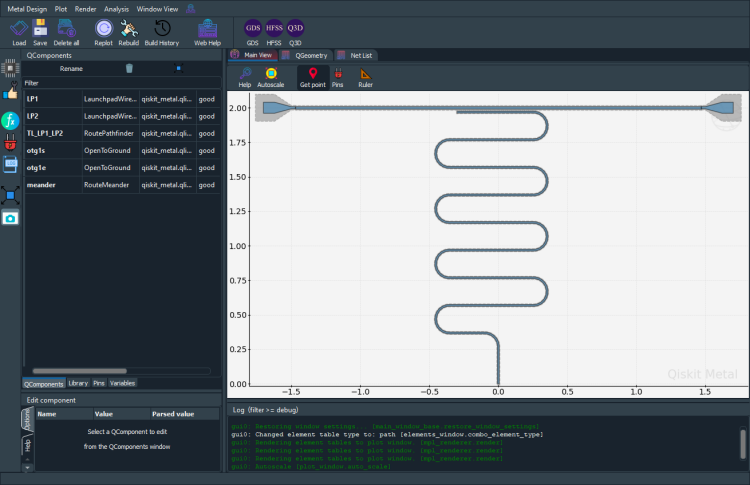

In [8]:
gui.autoscale()
gui.screenshot()

# Start the HFSS Driven Modal renderer for Ansys by passing arguments to QHFSSDrivenmodalPyaedt.
## The default will use default names for Ansys ProjectName and Ansys DesignName.

In [9]:
# Ansys will not start here since default for initiate is False.

# Example with defaults.
#hfss_dm_default = QHFSSDrivenmodalPyaedt(multiplanar_design)

hfss_dm = QHFSSDrivenmodalPyaedt(design, 'hfss_dm_project_1',
                                 'hfss_dm_design_1')

# # Ansys will start here.
# hfss_dm_2 = QHFSSDrivenmodalPyaedt(multiplanar_design,
#                                    'hfss_dm_project_2',
#                                    'hfss_dm_design_2',
#                                    initiate=True)

## Vacuum Box size given to renderer.

In [10]:
# Sample Holder options will determine the z values of vacuum box. 
hfss_dm.options["sample_holder_top"] = '1.0mm'
hfss_dm.options["sample_holder_bottom"] = '-1.0mm'
# hfss_dm.options['x_buffer_width_mm'] = 0.1
# hfss_dm.options['y_buffer_width_mm'] = 0.1

# Note, the xy size of vacuum box is determined by box_plus_buffer.  
# If False, the chip size will be used.
# If True, a buffer will be added to the box which contains the rendered components.

## Examine arguments to pass for Ansys-setup for driven modal.

In [11]:
"""Create a solution setup in Ansys HFSS Driven-Modal solution type. If user does not provide
    arguments, they will be obtained from QHFSSDrivenmodalPyaedt.default_setup dict.

    Args:
        name (str, optional): _description_. Defaults to None.
        SolveType (str, optional): Solution frequency type. Accepted values are in self.__supported_SolveType__.
                                Defaults to self.default_setup.
        Frequency (float, optional):  Minimum frequency in GHz. Defaults to self.default_setup.
        MaxDeltaE (float, optional):  This is correlated to MaxDeltaS. The definition
                                of MaxDeltaS is, absolute value of maximum difference in
                                scattering parameter S. Defaults to self.default_setup.
        MaximumPasses (int, optional):  Maximum number of passes. Defaults to self.default_setup.
        MinimumPasses (int, optional): Minimum number of passes.Defaults to self.default_setup.
        MinimumConvergedPasses (int, optional): Minimum number of converged passes. Defaults to self.default_setup.
        PercentRefinement (int, optional): Percent refinement. Defaults to self.default_setup.
        BasisOrder (int, optional): Basis order. Defaults to self.default_setup.
        MultipleAdaptiveFreqsSetup (dict, optional): Frequencies and their associated MaxDeltaS.
                                Defaults to self.default_setup.
        BroadbandLowFreq (float, optional): Minimum frequency for Broadband SolveType in GHz. 
                                Defaults to self.default_setup.
        BroadbandHighFreq (float, optional): Maximum frequency for Broadband SolveType in GHz. 
                                Defaults to self.default_setup.

    Returns:
        new_setup (pyaedt.modules.SolveSetup.SetupHFSS): pyAEDT simulation setup object.
"""

hfss_dm.default_setup

{'name': 'QHFSSDrivenmodalPyaedt_setup',
 'SolveType': 'Single',
 'Frequency': '5.0',
 'MaxDeltaE': '0.01',
 'MaximumPasses': '10',
 'MinimumPasses': '1',
 'MinimumConvergedPasses': '1',
 'PercentRefinement': '30',
 'BasisOrder': '1',
 'MultipleAdaptiveFreqsSetup': {'1GHz': [0.02],
  '2GHz': [0.02],
  '5GHz': [0.02]},
 'BroadbandLowFreq': '2',
 'BroadbandHighFreq': '8'}

## Add solution setup to Ansys Driven Modal.

In [12]:
# Ansys should add project and design for hfss_dm.
hfss_dm.add_hfss_dm_setup()

# Reduce MaxPass when running notebook as an example.
hfss_dm.add_hfss_dm_setup(name='fun_dm_1', MaximumPasses=3)


#### We have access to other solution frequency types as well
#### Normally it defaults to `SolveType=Single` (single frequency).

## 1. Multiple Frequencies
# multiple_freqs = OrderedDict([('4GHz', [0.01]),
#                               ('6GHz', [0.001]),
#                               ('11GHz', [0.0001])]) 
# hfss_dm.add_hfss_dm_setup(
#     name=None,
#     SolveType='MultiFrequency'
#     MultipleAdaptiveFreqsSetup=multiple_freqs)

## 2. Broadband
# hfss_dm.add_hfss_dm_setup(
#     name=None,
#     SolveType='Broadband',
#     BroadbandLowFreq="4",  # GHz
#     BroadbandHighFreq="11"  # GHz
# )

pyaedt INFO: using existing logger.


INFO:Global:using existing logger.


pyaedt INFO: AEDT installation Path C:\Program Files\AnsysEM\v232\Win64


INFO:Global:AEDT installation Path C:\Program Files\AnsysEM\v232\Win64


pyaedt INFO: Launching AEDT with the gRPC plugin.


...

pyaedt INFO: Successfully loaded project materials !


INFO:Global:Successfully loaded project materials !


pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


SetupName fun_dm_1 with 0 Sweeps

## Since user can edit the GUI, it is "better" to clean the user's project and design denoted when starting the renderer.

In [13]:
hfss_dm.clean_user_design()

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

pyaedt INFO: Successfully loaded project materials !


INFO:Global:Successfully loaded project materials !


pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


pyaedt WARNING: No objects to delete


# Render the multi-planar design using the similar convention as planar-design to identify ports.

In [14]:
open_terminations = []
# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('LP1', 'in', 50),
             ('LP2', 'in', 50)]
box_plus_buffer = True

hfss_dm.render_design(selection=[],
                      open_pins=open_terminations,
                      port_list=port_list,
                      box_plus_buffer=box_plus_buffer)

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

INFO:Global:Design Loaded


pyaedt INFO: Successfully loaded project materials !


INFO:Global:Successfully loaded project materials !


pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


## Examine arguments to pass for Ansys-sweep for driven modal.

```
Add a frequency sweep to a driven modal setup.

Args:
    setup_name (str, optional): Name of driven modal simulation setup.
                            Defaults to "QHFSSDrivenmodalPyaedt_setup".
    unit(str, optional): The units of start and stop.
    start_ghz (float, optional): Starting frequency of sweep in GHz.
                            Defaults to 2.0.
    stop_ghz (float, optional): Ending frequency of sweep in GHz.
                            Defaults to 8.0.
    count (int, optional): Total number of frequencies.
                            Defaults to 101.
    step_ghz (float, optional): Difference between adjacent
                            frequencies. Defaults to None.
    name (str, optional): Name of sweep. Defaults to "QHFSSDrivenmodalPyaedt_sweep".
    type (str, optional): Type of sweep.  Options are "Fast", "Interpolating",
                        and "Discrete". Defaults to "Fast".
    save_fields (bool, optional): Whether or not to save fields.
                        Defaults to False.
    interpolation_tol (float, optional): Error tolerance threshold 
                                for the interpolation type sweep. Defaults to 0.5.
    interpolation_max_solutions (int, optional): Maximum number of solutions
                                evaluted for the interpolation process. 
                                Defaults to 250.
```

In [15]:
# Add sweep for specific setup and give new name for sweep.

hfss_dm.add_sweep(setup_name='fun_dm_1',
                  name='fun_dm_1_sweep',
                  start_ghz=4.0,
                  stop_ghz=8.0,
                  count=2001,
                  type="Interpolating",
                  interpolation_tol=0.1,
                  interpolation_max_solutions=500)


pyaedt INFO: Linear count sweep fun_dm_1_sweep has been correctly created.


INFO:Global:Linear count sweep fun_dm_1_sweep has been correctly created.


# Select the name to analyze. Presently, we have two to choose from. 
## They are default=='QHFSSDrivenmodalPyaedt_setup' and 'fun_dm_1'.

In [16]:
# This has some error checking before using pyaedt's analyze_setup.
result_bool = hfss_dm.analyze_setup(setup_name='fun_dm_1',
                                    sweep_name='fun_dm_1_sweep')

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

INFO:Global:Materials Loaded


pyaedt INFO: Solving design setup fun_dm_1


INFO:Global:Solving design setup fun_dm_1


pyaedt INFO: Design setup fun_dm_1 solved correctly in 0.0h 0.0m 54.0s


INFO:Global:Design setup fun_dm_1 solved correctly in 0.0h 0.0m 54.0s


# Get the solution data!

## Can get scatter data, impedance, and admittance in format of mag/phase or real/imag. 

 ```
Get the solution data based on expressions.  Return output based on output_type.

Args:
    sweep_name (str): Name of sweep entry within setup.
    expressions (str, optional): This expression is either passed to get_solution_data
                                OR either S, Y or Z with port information will be
                                gathered by renderer. The renderer will get the
                                port names used with render_design() to create expressions.
                                So, the user MUST execute render_design() prior to
                                getting solution data.

                                Defaults to 'S'. S for scattering, Y for admittance, Z for
                                impedance.
    output_type (int, optional): 1 to return mag/phase,
                                2 to return real/imag,
                                3 to return mag/phase and real/imag.
                                Defaults to 1.

Returns:
    dict: Key is either mag, phase, real or imag based on output_type.
        The value is data from get_solution_data.
```

In [17]:
result_dict_default = hfss_dm.get_ansys_solution_data(
    sweep_name='fun_dm_1_sweep')

# To make more viewable, print some lines.
print()
print()
result_dict_default.keys()

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


pyaedt INFO: Solution Data Correctly Loaded.


INFO:Global:Solution Data Correctly Loaded.


dict_keys(['mag', 'phase'])

In [18]:
result_dict_s = hfss_dm.get_ansys_solution_data(sweep_name='fun_dm_1_sweep',
                                                expressions='S',
                                                output_type=3)
# To make more viewable, print some lines.
print()
print()
result_dict_s.keys()

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


pyaedt INFO: Solution Data Correctly Loaded.


INFO:Global:Solution Data Correctly Loaded.


dict_keys(['mag', 'phase', 'real', 'imag'])

## Remove the hash mark to retrieve the type of data you want to retrieve from Scatter Solution Data. 

In [19]:
# Remove comment to view all frequencies. 
#result_dict_s

# Remove comment to view pandas dataframe for magnitude for all frequencies for scatter solution data. 
#result_dict_s['mag']

# Remove comment to view pandas dataframe for real data for all frequencies for scatter solution data.
#result_dict_s['real']

In [20]:
# Example of getting impedance data.
result_dict_z = hfss_dm.get_ansys_solution_data(sweep_name='fun_dm_1_sweep',
                                                expressions='Z',
                                                output_type=3)
result_dict_s['mag']

pyaedt INFO: Project hfss_dm_project_1 set to active.


INFO:Global:Project hfss_dm_project_1 set to active.


pyaedt INFO: Aedt Objects initialized


INFO:Global:Aedt Objects initialized


pyaedt INFO: Variable Manager initialized


...

pyaedt INFO: Materials Loaded


INFO:Global:Materials Loaded


pyaedt INFO: Solution Data Correctly Loaded.


INFO:Global:Solution Data Correctly Loaded.


,"S(Port_LP1_in,Port_LP1_in)","S(Port_LP1_in,Port_LP2_in)","S(Port_LP2_in,Port_LP1_in)","S(Port_LP2_in,Port_LP2_in)"
4.000,0.438662,0.898652,0.898652,0.438662
4.002,0.438808,0.898581,0.898581,0.438808
4.004,0.438954,0.898509,0.898509,0.438954
4.006,0.439100,0.898438,0.898438,0.439100
4.008,0.439246,0.898367,0.898367,0.439246
...,...,...,...,...
7.992,0.594587,0.804031,0.804031,0.594587
7.994,0.594607,0.804017,0.804017,0.594607
7.996,0.594627,0.804002,0.804002,0.594627
7.998,0.594647,0.803987,0.803987,0.594647


Index(['S(Port_LP1_in,Port_LP1_in)', 'S(Port_LP1_in,Port_LP2_in)',
       'S(Port_LP2_in,Port_LP1_in)', 'S(Port_LP2_in,Port_LP2_in)'],
      dtype='object')


<Axes: >

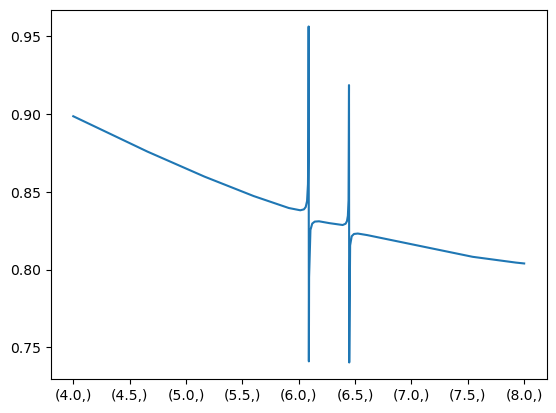

In [21]:
%matplotlib inline
key = 'mag' # 'mag', 'phase', 'real', 'imag'

print(result_dict_s[key].columns)
result_dict_s[key]['S(Port_LP2_in,Port_LP1_in)'].plot()
#result_dict_s[key].plot()

In [22]:
# Will disconnect Metal from Ansys, and leave Ansys open.
# If the python script closes, the OS will most likely close Ansys.
# hfss_dm.close()


# Will close Ansys.
#hfss_dm.force_exit_ansys()